# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [2]:
# Lendo o arquivo CSV
# O arquivo está separado por vírgula, então não precisei usar delimiter=';'
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Antes de sair calculando qualquer coisa, eu sempre dou uma olhada geral na base: quantas linhas e colunas ela tem, qual o tipo de cada coluna e se existem valores ausentes. Isso evita surpresa na hora de calcular médias, medianas etc.

In [3]:
# Conferindo o tamanho da base
print(f"A base tem {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# Conferindo o tipo de cada coluna
print("Tipos de dados de cada coluna:")
print(df.dtypes)

# Conferindo se existem valores ausentes (NaN)
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

# Conferindo quantos produtos têm Preco_Normal igual a 0
print(f"\nQuantidade de produtos com Preco_Normal = 0: {(df['Preco_Normal'] == 0).sum()}")

A base tem 1107 linhas e 7 colunas.

Tipos de dados de cada coluna:
title             object
Marca             object
Preco_Normal       int64
Preco_Desconto     int64
Preco_Anterior     int64
Desconto           int64
Categoria         object
dtype: object

Valores ausentes por coluna:
title             0
Marca             0
Preco_Normal      0
Preco_Desconto    0
Preco_Anterior    0
Desconto          0
Categoria         0
dtype: int64

Quantidade de produtos com Preco_Normal = 0: 294


**O que encontrei na verificação:**

Não tem nenhum valor ausente (NaN) na base — as 1.107 linhas estão completas nas 7 colunas, então não precisei tratar nenhum "buraco" nos dados. As colunas `Preco_Normal`, `Preco_Desconto`, `Preco_Anterior` e `Desconto` já vieram como números inteiros (`int64`), então também não precisei converter nada de texto para número.

Uma coisa que achei importante registrar: encontrei **294 produtos (cerca de 27% da base) com `Preco_Normal` igual a 0**. Eu decidi não excluir essas linhas, porque o objetivo aqui é calcular tudo a partir da base exatamente como ela foi enviada, mas vale deixar anotado que provavelmente são produtos sem preço cadastrado no momento da coleta (e não produtos realmente "grátis"). Isso é algo que pode estar puxando algumas médias um pouco para baixo, principalmente em categorias com mais casos assim — vou comentar isso de novo quando aparecer relevante nas próximas análises.

Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.




As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.

As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [4]:
# Calculando a média do preço normal por categoria
media_por_categoria = df.groupby('Categoria')['Preco_Normal'].mean().round(2)
media_por_categoria

Categoria
belleza-y-cuidado-personal    1783.56
comidas-preparadas            3095.04
congelados                    2108.04
frutas                        1724.47
instantaneos-y-sopas           765.49
lacteos                       2385.22
verduras                      1343.30
Name: Preco_Normal, dtype: float64

In [5]:
# Calculando a mediana do preço normal por categoria
mediana_por_categoria = df.groupby('Categoria')['Preco_Normal'].median()
mediana_por_categoria

Categoria
belleza-y-cuidado-personal    1569.0
comidas-preparadas            3290.0
congelados                    1519.0
frutas                        1195.0
instantaneos-y-sopas           439.0
lacteos                        989.0
verduras                      1180.0
Name: Preco_Normal, dtype: float64

In [6]:
# Juntando média e mediana em uma única tabela para facilitar a comparação
tabela_media_mediana = pd.DataFrame({
    'Media': media_por_categoria,
    'Mediana': mediana_por_categoria
})

# Coluna auxiliar: True quando a média está acima da mediana
tabela_media_mediana['Media_acima_da_mediana'] = tabela_media_mediana['Media'] > tabela_media_mediana['Mediana']

tabela_media_mediana.sort_values('Media', ascending=False)

,Media,Mediana,Media_acima_da_mediana
Categoria,,,
comidas-preparadas,3095.04,3290.0,False
lacteos,2385.22,989.0,True
congelados,2108.04,1519.0,True
belleza-y-cuidado-personal,1783.56,1569.0,True
frutas,1724.47,1195.0,True
verduras,1343.30,1180.0,True
instantaneos-y-sopas,765.49,439.0,True


## Análise da média e mediana por categoria

**Categorias com média acima da mediana:** lacteos, congelados, belleza-y-cuidado-personal, frutas, verduras e instantaneos-y-sopas.

**Categoria com média abaixo da mediana:** comidas-preparadas.

Na minha análise, quando a média ficou maior que a mediana, entendi que alguns produtos mais caros estavam puxando o valor médio para cima. Isso aconteceu principalmente em **lacteos**, onde a média ficou bem mais alta que a mediana.

Em **comidas-preparadas**, a média ficou um pouco abaixo da mediana. Olhando a base, percebi que existem alguns produtos com `Preco_Normal` igual a zero, e esses valores podem estar puxando a média para baixo.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [7]:
# Calculando média, mediana e desvio padrão por categoria
tabela_dispersao = df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median', 'std']).round(2)
tabela_dispersao.columns = ['Media', 'Mediana', 'Desvio_Padrao']
tabela_dispersao = tabela_dispersao.sort_values('Desvio_Padrao', ascending=False)
tabela_dispersao

,Media,Mediana,Desvio_Padrao
Categoria,,,
lacteos,2385.22,989.0,3925.82
belleza-y-cuidado-personal,1783.56,1569.0,2210.04
congelados,2108.04,1519.0,2111.54
comidas-preparadas,3095.04,3290.0,2019.91
frutas,1724.47,1195.0,1639.15
instantaneos-y-sopas,765.49,439.0,1170.23
verduras,1343.30,1180.0,1012.70


## Análise do desvio padrão

A categoria com o **maior desvio padrão é lacteos**, com 3.925,82. Isso mostra que os preços dessa categoria variam bastante.

Também observei que, em lacteos, a média ficou muito acima da mediana. Isso indica que existem alguns produtos bem mais caros dentro da categoria, puxando a média para cima. Ou seja, o preço típico da categoria é mais próximo da mediana, mas alguns produtos com preço alto aumentam bastante a média.

Nas categorias com maior desvio padrão, a diferença entre média e mediana tende a ser maior, porque existe mais variação entre os preços dos produtos.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

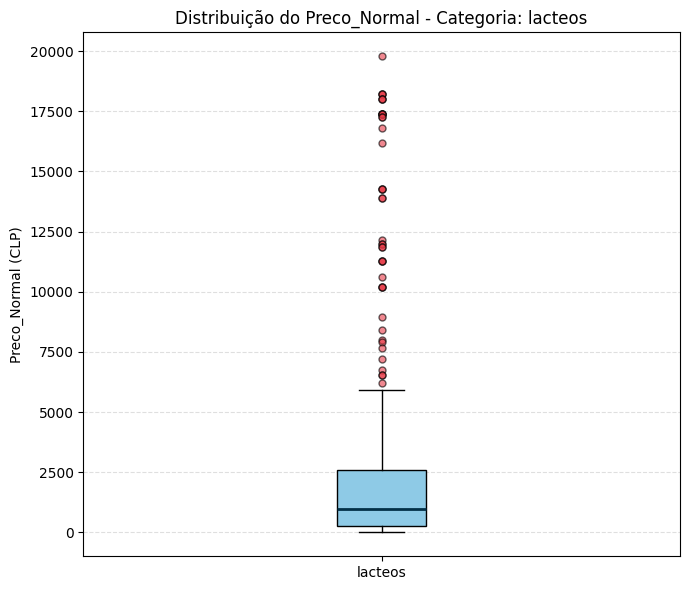

In [8]:
# A categoria com maior desvio padrão foi lacteos
categoria_maior_desvio = 'lacteos'
dados_categoria = df.loc[df['Categoria'] == categoria_maior_desvio, 'Preco_Normal']

plt.figure(figsize=(7, 6))
plt.boxplot(dados_categoria, vert=True, patch_artist=True,
            boxprops=dict(facecolor='#8ecae6'),
            medianprops=dict(color='#023047', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='#e63946', markersize=5, alpha=0.6))
plt.title(f'Distribuição do Preco_Normal - Categoria: {categoria_maior_desvio}')
plt.ylabel('Preco_Normal (CLP)')
plt.xticks([1], [categoria_maior_desvio])
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('boxplot_lacteos_preco_normal.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Calculando os limites do boxplot para identificar os outliers
q1 = dados_categoria.quantile(0.25)
q3 = dados_categoria.quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr

outliers = dados_categoria[dados_categoria > limite_superior]

print(f"Q1: {q1}")
print(f"Mediana: {dados_categoria.median()}")
print(f"Q3: {q3}")
print(f"IQR (Q3 - Q1): {iqr}")
print(f"Limite superior para outliers: {limite_superior}")
print(f"Maior valor da categoria: {dados_categoria.max()}")
print(f"\nQuantidade de outliers acima do limite superior: {len(outliers)}")
print(f"Isso representa {len(outliers) / len(dados_categoria) * 100:.2f}% dos produtos de lacteos")

Q1: 269.0
Mediana: 989.0
Q3: 2609.0
IQR (Q3 - Q1): 2340.0
Limite superior para outliers: 6119.0
Maior valor da categoria: 19788

Quantidade de outliers acima do limite superior: 43
Isso representa 9.62% dos produtos de lacteos


In [10]:
# Visualizando alguns produtos classificados como outliers em lacteos
produtos_outliers = df.loc[
    (df['Categoria'] == 'lacteos') &
    (df['Preco_Normal'] > limite_superior),
    ['title', 'Marca', 'Preco_Normal']
].sort_values('Preco_Normal', ascending=False)

produtos_outliers.head(10)


,title,Marca,Preco_Normal
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388


**Como os preços estão distribuídos?**

No boxplot de **lacteos**, a maior parte dos produtos fica concentrada em valores mais baixos. A mediana está em 989,00, enquanto o terceiro quartil fica em 2.609,00. Isso mostra que metade dos produtos da categoria está abaixo desse intervalo de preço.

**Existem muitos outliers?**

Sim. Foram encontrados **43 outliers** acima do limite superior de 6.119,00, o que representa quase 10% dos produtos da categoria.

**O que esses outliers podem representar?**

A maior parte dos outliers são produtos em embalagens maiores, como packs de leite e leite em pó. Então, nesse caso, os outliers não parecem ser erro na base. Eles representam produtos diferentes dentro da mesma categoria, principalmente embalagens maiores ou produtos com maior valor agregado.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

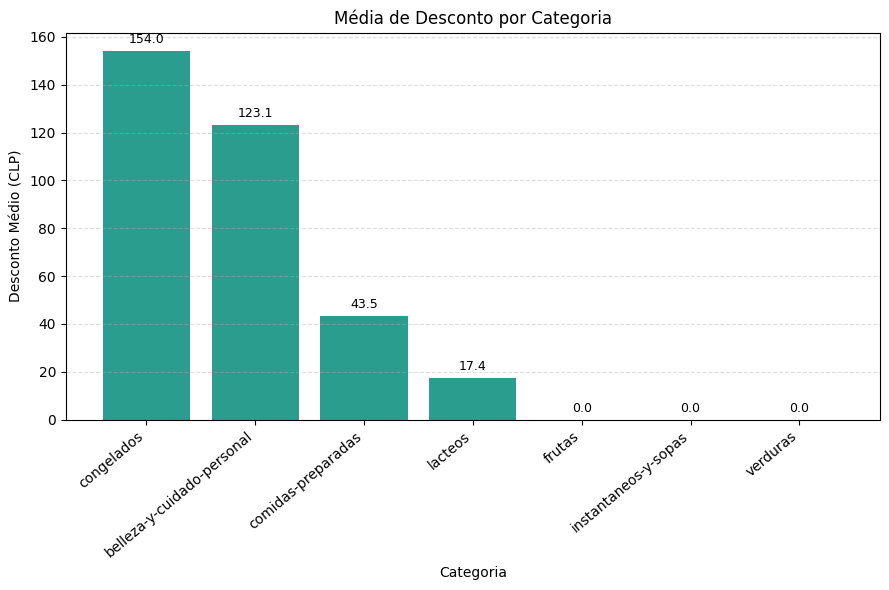

Categoria
congelados                    154.03
belleza-y-cuidado-personal    123.08
comidas-preparadas             43.48
lacteos                        17.41
frutas                          0.00
instantaneos-y-sopas            0.00
verduras                        0.00
Name: Desconto, dtype: float64

In [11]:
# Calculando a média de desconto por categoria, da maior para a menor
desconto_medio = df.groupby('Categoria')['Desconto'].mean().round(2).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
barras = plt.bar(desconto_medio.index, desconto_medio.values, color='#2a9d8f')
plt.title('Média de Desconto por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Desconto Médio (CLP)')
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o valor acima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 2, f'{altura:.1f}',
              ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('media_desconto_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

desconto_medio

In [12]:
# Verificando quantos produtos realmente possuem desconto por categoria
resumo_descontos = df.groupby('Categoria').agg(
    Total_Produtos=('title', 'count'),
    Produtos_Com_Desconto=('Desconto', lambda x: (x > 0).sum()),
    Media_Desconto=('Desconto', 'mean')
).reset_index()

resumo_descontos['Percentual_Com_Desconto'] = (
    resumo_descontos['Produtos_Com_Desconto'] / resumo_descontos['Total_Produtos'] * 100
).round(1)

resumo_descontos['Media_Desconto'] = resumo_descontos['Media_Desconto'].round(2)
resumo_descontos.sort_values('Media_Desconto', ascending=False)


,Categoria,Total_Produtos,Produtos_Com_Desconto,Media_Desconto,Percentual_Com_Desconto
2,congelados,235,60,154.03,25.5
0,belleza-y-cuidado-personal,239,43,123.08,18.0
1,comidas-preparadas,46,4,43.48,8.7
5,lacteos,447,11,17.41,2.5
3,frutas,19,0,0.00,0.0
4,instantaneos-y-sopas,57,0,0.00,0.0
6,verduras,64,0,0.00,0.0


**Quais categorias recebem mais desconto?**

A categoria com o **maior desconto médio é congelados**, com 154,03 por produto, seguida de **belleza-y-cuidado-personal** e **comidas-preparadas**.

Também observei que **frutas, instantaneos-y-sopas e verduras** tiveram média de desconto igual a zero nessa base. Isso indica que, na coleta analisada, essas categorias não estavam com descontos registrados.

Outro ponto importante é que congelados teve o maior desconto médio mesmo sem todos os produtos estarem em promoção. Isso sugere que, quando existe desconto nessa categoria, ele costuma ser mais relevante.

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [13]:
# Agrupando por Categoria e Marca para criar o treemap interativo
df_treemap = df.groupby(['Categoria', 'Marca']).agg(
    Desconto_Medio=('Desconto', 'mean'),
    Quantidade_Produtos=('title', 'count')
).reset_index()

df_treemap['Desconto_Medio'] = df_treemap['Desconto_Medio'].round(2)

fig = px.treemap(
    df_treemap,
    path=['Categoria', 'Marca'],
    values='Quantidade_Produtos',
    color='Desconto_Medio',
    color_continuous_scale='RdYlGn',
    custom_data=['Desconto_Medio'],
    title='Média de Desconto por Categoria e Marca'
)

fig.update_traces(
    hovertemplate='<b>%{label}</b><br>' +
                  'Qtd. produtos: %{value}<br>' +
                  'Desconto médio: %{customdata[0]:.2f}<extra></extra>'
)

# Salvando também em HTML para facilitar a visualização do gráfico interativo fora do notebook
fig.write_html('treemap_desconto_categoria_marca.html')
fig.show()

**Interpretando o treemap:**

Nesse gráfico interativo, cada bloco grande representa uma categoria e, dentro dele, aparecem as marcas. O tamanho do bloco representa a quantidade de produtos e a cor mostra a média de desconto.

Com isso, dá para perceber que os maiores descontos médios aparecem principalmente em algumas marcas de **congelados**, **lacteos** e **belleza-y-cuidado-personal**. O gráfico também ajuda a comparar rapidamente marcas dentro da mesma categoria.

A vantagem do treemap é que ele permite navegar entre categoria e marca, facilitando a análise visual dos descontos sem precisar olhar apenas para tabelas.

# Conclusão geral do projeto

Nesta análise, trabalhei com uma base de produtos de um supermercado chileno com 1.107 registros, divididos em 7 categorias. A base não tinha valores ausentes, mas apresentou alguns produtos com `Preco_Normal` igual a zero, o que foi importante considerar na interpretação dos resultados.

A categoria com maior variação de preço foi **lacteos**. O boxplot mostrou vários outliers, principalmente produtos em embalagens maiores, como packs de leite e leite em pó. Por isso, a média dessa categoria ficou bem acima da mediana.

Nas análises de desconto, **congelados** teve a maior média de desconto, seguido por **belleza-y-cuidado-personal**. Já frutas, verduras e instantaneos-y-sopas não apresentaram descontos na base analisada.

Como insight comercial, o supermercado poderia analisar lacteos separando produtos individuais de embalagens maiores, porque misturar tudo na mesma comparação pode distorcer a leitura dos preços. Também seria interessante avaliar campanhas pontuais para categorias sem desconto, principalmente perecíveis, desde que isso faça sentido para a margem e para a validade dos produtos.